[0.027579817614499236, 0.014011601898842208, 0.007085532113147219]
Pente q (régression linéaire) : 0.9803


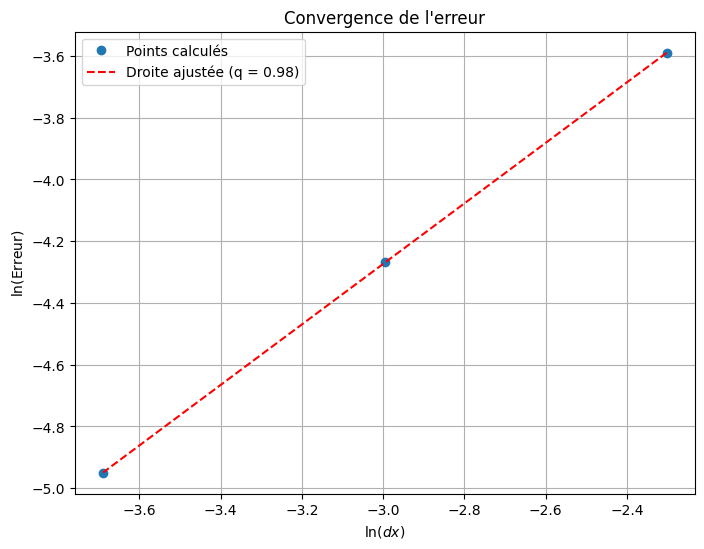

In [ ]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

C = 1.0
D = 1.0
Nt = 50
L = 1.0

#Cas_1
def u_exacte(x, t):
    return np.cos(np.pi * x) * (1 + t)

def f(x, t):
    return np.cos(np.pi * x)+ D * ((np.pi**2) * np.cos(np.pi * x) * (1 + t)) - C * (np.pi * np.sin(np.pi * x) * (1 + t))

"""#Cas_2
def u_exacte(x,t):
  return np.sin(np.pi*x)*np.exp(-t)

def f(x, t):
    return -np.sin(np.pi*x)*np.exp(-t)+D*((np.pi**2)*np.sin(np.pi*x)*np.exp(-t))+C*(np.pi*np.cos(np.pi*x)*np.exp(-t))"""

"""#Cas_3
def u_exacte(x,t):
  return (np.sin(np.pi * x) + np.cos(2*np.pi*x))*np.exp(-(np.pi**2)*t)

#Fonction source
def f(x, t):
    return -(np.pi**2)*(np.sin(np.pi * x) + np.cos(2*np.pi*x))*np.exp(-(np.pi**2)*t) + D*((np.pi**2) * (np.sin(np.pi * x) + 4*np.cos(2*np.pi*x))*np.exp(-(np.pi**2)*t)) + C*((np.pi * np.cos(np.pi * x) -2*np.pi*np.sin(2*np.pi*x))* np.exp(-(np.pi**2)*t))
"""

def calcul_ln_erreur(dx, dx_values2):
    dt = min(dx_values2)/(2*D)
    Nx = int(L / dx)
    T = Nt * dt

    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    u_calculé = np.zeros((Nx, Nt))

    u_calculé[:, 0] = u_exacte(x, 0)

    v = (C * dt) / dx
    gamma = (D * dt) / (dx**2)
    assert gamma <= 0.5
    assert v<=1

    for n in range(Nt - 1):
        for i in range(1, Nx - 1):
            if C >=0:
                du = u_calculé[i, n] - u_calculé[i - 1, n]
            else:
                du = u_calculé[i + 1, n] - u_calculé[i, n]
            u_calculé[i, n + 1] = u_calculé[i, n]+ gamma * (u_calculé[i + 1, n] - 2 * u_calculé[i, n] + u_calculé[i - 1, n])- v * du + f(x[i], t[n]) * dt

        # Conditions aux limites Cas_1
        u_calculé[0, n + 1] = 1 + t[n + 1]
        u_calculé[-1, n + 1] = -(1 + t[n + 1])

        """#Conditions aux limites Cas_2
        u_calculé[0, n+1] = 0
        u_calculé[-1, n+1] = 0"""

        """#Conditions aux limites Cas_3
        u_calculé[0, n+1] = np.exp(-(np.pi**2)*t[n+1])
        u_calculé[-1, n+1] = np.exp(-(np.pi**2)*t[n+1])"""

    erreur = np.abs(u_calculé[:, -1] - u_exacte(x, T))
    norme_Linf = np.max(np.abs(erreur))
    return norme_Linf

dx_values = [1/10, 1/20, 1/40]
dx_values2 = [(1/10)**2, (1/20)**2, (1/40)**2]
E = [calcul_ln_erreur(dx, dx_values2) for dx in dx_values]
print(E)
ln_dx = np.log(dx_values)
ln_E=np.log(E)

# Régression linéaire
slope, intercept, rvalue, pvalue, stderr= linregress(ln_dx, ln_E)
print(f"Pente q (régression linéaire) : {slope:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(ln_dx, ln_E, 'o', label='Points calculés')
plt.plot(ln_dx, slope * ln_dx + intercept, 'r--', label=f'Droite ajustée (q = {slope:.2f})')
plt.xlabel(r'$\ln(dx)$')
plt.ylabel(r'$\ln(\text{Erreur})$')
plt.title('Convergence de l\'erreur')
plt.legend()
plt.grid(True)
plt.show()


